# Chapter 03 - Dimensionality Reduction
## Techniques for Reducing Features and Preserving Information
Based on scikit-learn Cookbook. This notebook focuses on PCA and dimensionality reduction workflows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
plt.style.use('ggplot')

## 1. Load Dataset

In [2]:
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
X.shape

(178, 13)

Dataset contains many numeric features. PCA helps reduce dimensions while preserving important variance.

## 2. Standardize Features

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Apply PCA (All Components)

In [4]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
cum = explained.cumsum()

## 4. Explained Variance Plot

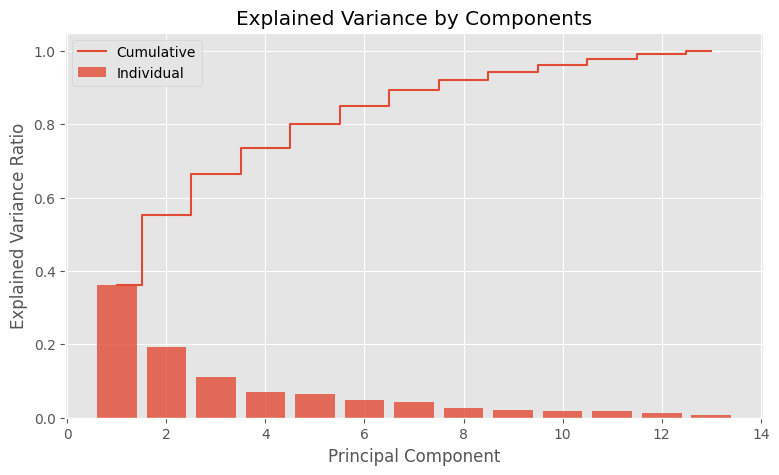

In [5]:
plt.figure(figsize=(9,5))
plt.bar(range(1,len(explained)+1), explained, alpha=0.8, label='Individual')
plt.step(range(1,len(cum)+1), cum, where='mid', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.legend()
plt.show()

**Description:** Bars represent variance captured by each principal component. The line shows cumulative explained variance used to choose optimal dimensions.

## 5. PCA with 2 Components

In [6]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

## 6. 2D PCA Projection

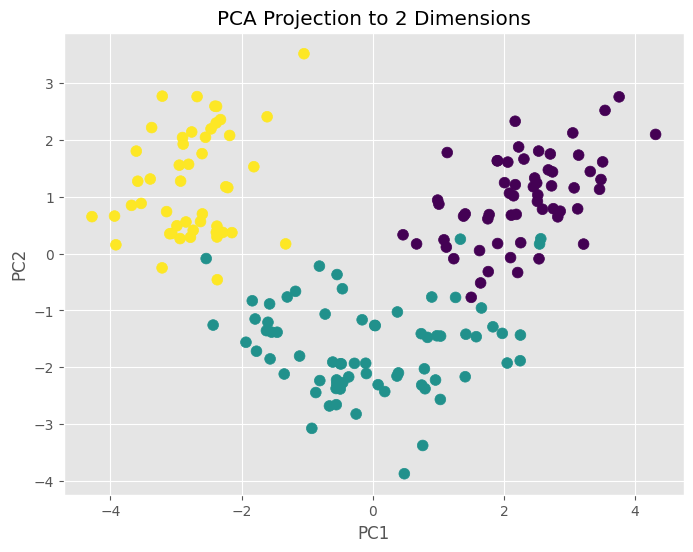

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection to 2 Dimensions')
plt.show()

**Description:** Data originally had many features. PCA projects samples into two dimensions while maintaining major structure and class separation.

## 7. Compare Model Accuracy (Original vs PCA)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)
acc_original = accuracy_score(y_test, pred)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2d, y, test_size=0.25, random_state=42, stratify=y)
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2, y_train2)
pred2 = model2.predict(X_test2)
acc_pca = accuracy_score(y_test2, pred2)
print('Original Accuracy:', round(acc_original,4))
print('PCA(2 Components) Accuracy:', round(acc_pca,4))

Original Accuracy: 0.9778
PCA(2 Components) Accuracy: 0.9111


## 8. Accuracy Comparison Chart

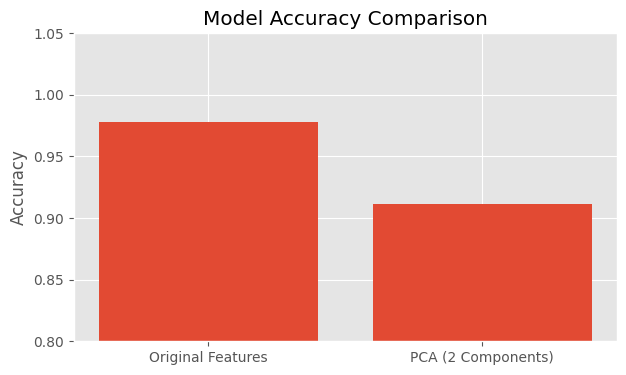

In [9]:
plt.figure(figsize=(7,4))
plt.bar(['Original Features','PCA (2 Components)'], [acc_original, acc_pca])
plt.ylim(0.8,1.05)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

**Description:** PCA can reduce dimensionality significantly while keeping model performance competitive.

## Important Concepts
- Curse of Dimensionality
- PCA transforms correlated features into orthogonal components
- Feature compression
- Noise reduction
- Faster training with fewer dimensions

## Summary
Dimensionality reduction helps simplify datasets while preserving useful information. PCA is one of the most widely used techniques for visualization, compression, and improving efficiency.